In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")

In [3]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [7]:
dataset[['Purchased']].value_counts()

Purchased
0            257
1            143
Name: count, dtype: int64

In [8]:
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

In [9]:
dataset

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1
...,...,...,...,...,...
395,15691863,46,41000,1,0
396,15706071,51,23000,1,1
397,15654296,50,20000,1,0
398,15755018,36,33000,0,1


In [10]:
dataset.columns

Index(['User ID', 'Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [11]:
independent = dataset[['User ID', 'Age', 'EstimatedSalary','Gender_Male']]

In [12]:
dependent = dataset[['Purchased']]

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(independent, dependent, test_size=0.30, random_state=0)

In [15]:
from sklearn.tree import DecisionTreeClassifier
classifier= DecisionTreeClassifier(criterion="entropy",splitter="random")
classifier.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', splitter='random')

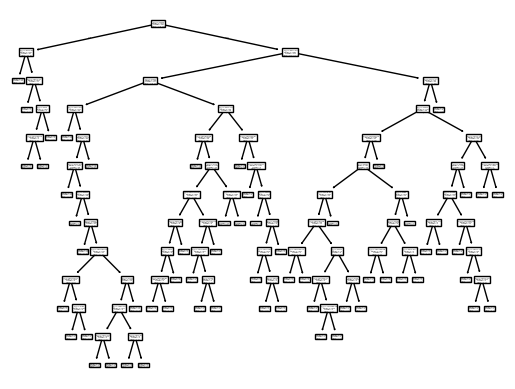

In [16]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(classifier)
plt.show()

In [17]:
y_predict = classifier.predict(X_test)

In [18]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_predict)

In [19]:
print(cm)

[[71  8]
 [12 29]]


In [20]:
from sklearn.metrics import classification_report
clf_report = classification_report(y_test,y_predict)

In [21]:
print(clf_report)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        79
           1       0.78      0.71      0.74        41

    accuracy                           0.83       120
   macro avg       0.82      0.80      0.81       120
weighted avg       0.83      0.83      0.83       120

